# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [4]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [5]:
#Seu código aqui para a média
media_por_categoria = df.groupby('Categoria')['Preco_Normal'].mean().reset_index()
media_por_categoria.columns = ['Categoria', 'Média de Preço']

print("--- Média por Categoria ---")
print(media_por_categoria)

--- Média por Categoria ---
                    Categoria  Média de Preço
0  belleza-y-cuidado-personal     1783.556485
1          comidas-preparadas     3095.043478
2                  congelados     2108.042553
3                      frutas     1724.473684
4        instantaneos-y-sopas      765.491228
5                     lacteos     2385.219239
6                    verduras     1343.296875


In [6]:
#Seu código aqui para a mediana
mediana_por_categoria = df.groupby('Categoria')['Preco_Normal'].median().reset_index()
mediana_por_categoria.columns = ['Categoria', 'Mediana de Preço']

print("--- Mediana por Categoria ---")
print(mediana_por_categoria)

--- Mediana por Categoria ---
                    Categoria  Mediana de Preço
0  belleza-y-cuidado-personal            1569.0
1          comidas-preparadas            3290.0
2                  congelados            1519.0
3                      frutas            1195.0
4        instantaneos-y-sopas             439.0
5                     lacteos             989.0
6                    verduras            1180.0


Digite aqui as categorias:
- CATEGORIAS COM MÉDIA ACIMA DA MEDIANA
belleza-y-cuidado-personal: Média (1783.55) > Mediana (1569.0)
congelados: Média (2108.04) > Mediana (1519.0)
frutas: Média (1724.47) > Mediana (1195.0)
instantaneos-y-sopas: Média (765.49) > Mediana (439.0)
lacteos: Média (2385.21) > Mediana (989.0) — Destaque para a grande diferença.
verduras: Média (1343.29) > Mediana (1180.0)

- CATEGORIAS COM MÉDIA ABAIXO DA MEDIANA
comidas-preparadas: Média (3095.04) < Mediana (3290.0)

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [7]:
#Seu código aqui
desvio_padrao = df.groupby('Categoria')['Preco_Normal'].std().reset_index()
desvio_padrao.columns = ['Categoria', 'Desvio Padrão (CLP)']
print(desvio_padrao.sort_values(by='Desvio Padrão (CLP)', ascending=False).round(2))

                    Categoria  Desvio Padrão (CLP)
5                     lacteos              3925.82
0  belleza-y-cuidado-personal              2210.04
2                  congelados              2111.54
1          comidas-preparadas              2019.91
3                      frutas              1639.15
4        instantaneos-y-sopas              1170.23
6                    verduras              1012.70


Digite nesse campo o comportamento que você identificou.
A Média é puxada para cima por causa de alguns produtos muito caros, enquanto a Mediana mostra que na realidade, a maioria dos produtos custa bem menos que essa média.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

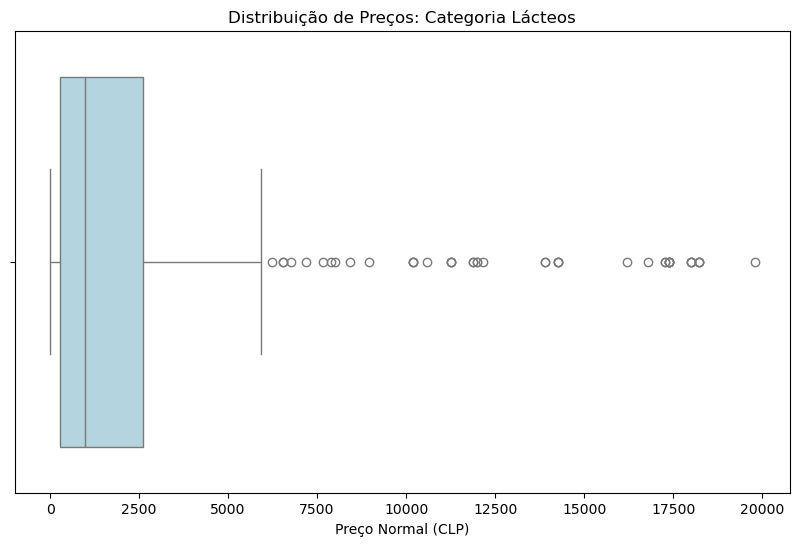

In [11]:
#Seu código aqui
import seaborn as sns
import matplotlib.pyplot as plt
df_maior_desvio = df.loc[df['Categoria'] == 'lacteos']

# Criando o Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_maior_desvio['Preco_Normal'], color='lightblue')

plt.title('Distribuição de Preços: Categoria Lácteos')
plt.xlabel('Preço Normal (CLP)')
plt.show()

A distribuição é crescente a direita, indicando os preços altos. Isso aponta muitos outliers após o "bigode" direito do gráfico, indicando nesses itens a responsabilidade pelo desvio padrão ser elevado e puxar a média pra cima. 

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

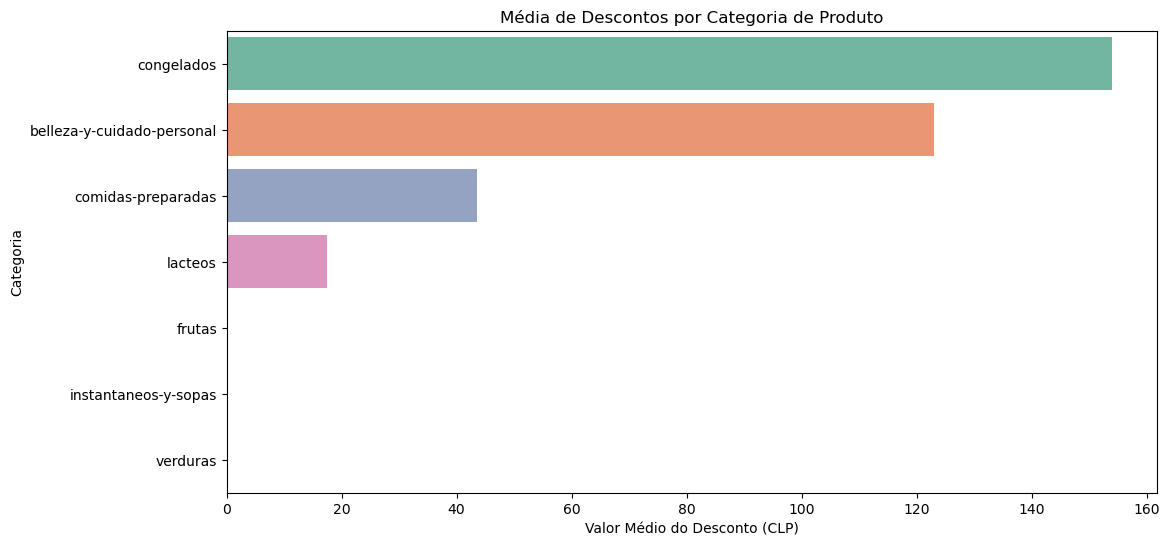

In [12]:
# Seu código aqui
import seaborn as sns
import matplotlib.pyplot as plt

# 1. média de descontos agrupada por categoria
media_descontos = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False).reset_index()

# 2. gráfico de barras
plt.figure(figsize=(12, 6))


sns.barplot(
    data=media_descontos,
    x='Desconto',
    y='Categoria',
    hue='Categoria',
    palette='Set2',
    legend=False
)

# 3. Ajustes visuais
plt.title('Média de Descontos por Categoria de Produto')
plt.xlabel('Valor Médio do Desconto (CLP)')
plt.ylabel('Categoria')
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

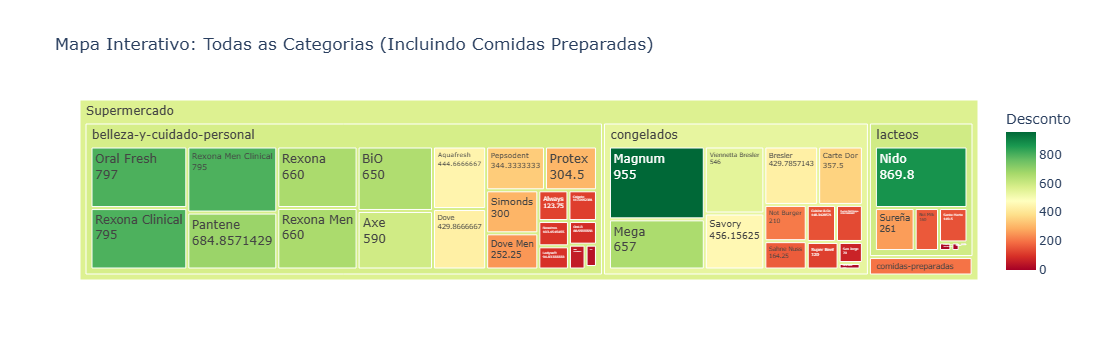

In [14]:
# Seu código aqui
import plotly.express as px
import pandas as pd
import numpy as np


df = pd.read_csv('MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv')

df['Desconto'] = df['Desconto'].fillna(0)

df_completo = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

df_completo['Tamanho_Quadrado'] = df_completo['Desconto'].apply(lambda x: x if x > 0 else 0.1)

fig = px.treemap(
    df_completo,
    path=[px.Constant("Supermercado"), 'Categoria', 'Marca'], # Adicionei uma base comum
    values='Tamanho_Quadrado', # Usamos o tamanho ajustado para garantir a exibição
    color='Desconto',           # A cor continua sendo o desconto real
    color_continuous_scale='RdYlGn',
    hover_data={'Desconto': True, 'Tamanho_Quadrado': False}, # Esconde o valor de ajuste no mouse
    title='Mapa Interativo: Todas as Categorias (Incluindo Comidas Preparadas)'
)

fig.update_traces(textinfo="label+value")

fig.show()